In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load California Housing dataset
housing = fetch_california_housing()

# Features and Target
X = housing.data
y = housing.target

# Create DataFrame
df = pd.DataFrame(X, columns=housing.feature_names)
df['Price'] = y

# Display first 5 rows
print("First 5 rows of dataset:")
print(df.head())

# Dataset information
print("\nDataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows of dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Dataset Shape: (20640, 9)

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


In [3]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
lr_predictions = lr_model.predict(X_test)

# Evaluate the model
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("\n===== Linear Regression Results =====")
print(f"RMSE : {lr_rmse:.4f}")
print(f"R² Score : {lr_r2:.4f}")

Training samples: 16512
Testing samples: 4128

===== Linear Regression Results =====
RMSE : 0.7456
R² Score : 0.5758


In [4]:
print("\n===== 5-Fold Cross Validation =====")

cv_scores = cross_val_score(
    lr_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:")
print(cv_scores)

print(f"\nAverage CV Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")


===== 5-Fold Cross Validation =====
Cross Validation Scores:
[0.62011512 0.61298876 0.6134416  0.61069973 0.60017477]

Average CV Score: 0.6115
Standard Deviation: 0.0065


In [5]:
print("\n===== Hyperparameter Tuning using GridSearchCV =====")

# Create Decision Tree model
dt_model = DecisionTreeRegressor(random_state=42)

# Define hyperparameters to test
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search with 5-Fold Cross Validation
grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Train GridSearch
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(f"{grid_search.best_score_:.4f}")


===== Hyperparameter Tuning using GridSearchCV =====

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}

Best Cross Validation Score:
0.7101


In [6]:
print("\n===== Evaluating Tuned Decision Tree =====")

# Predictions using tuned model
dt_predictions = best_model.predict(X_test)

# Metrics
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))
dt_r2 = r2_score(y_test, dt_predictions)

print(f"Decision Tree RMSE : {dt_rmse:.4f}")
print(f"Decision Tree R² Score : {dt_r2:.4f}")

print("\n===== Model Comparison =====")

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree (Tuned)"],
    "RMSE": [lr_rmse, dt_rmse],
    "R2 Score": [lr_r2, dt_r2]
})

print(comparison)


===== Evaluating Tuned Decision Tree =====
Decision Tree RMSE : 0.6391
Decision Tree R² Score : 0.6883

===== Model Comparison =====
                   Model      RMSE  R2 Score
0      Linear Regression  0.745581  0.575788
1  Decision Tree (Tuned)  0.639065  0.688338


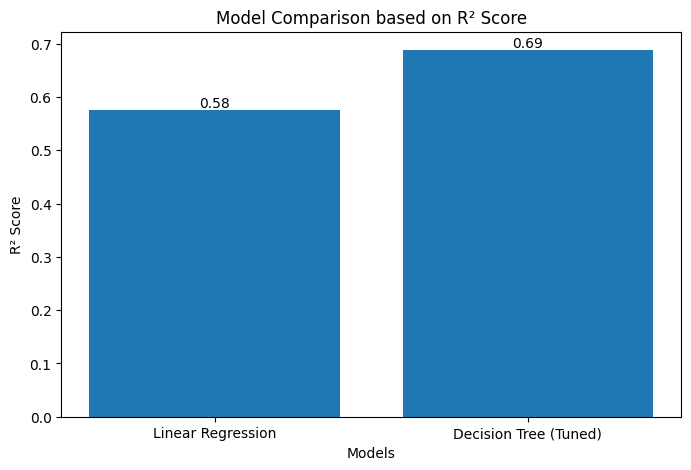

In [7]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["R2 Score"])

plt.title("Model Comparison based on R² Score")
plt.xlabel("Models")
plt.ylabel("R² Score")

for i, score in enumerate(comparison["R2 Score"]):
    plt.text(i, score, f"{score:.2f}", ha='center', va='bottom')

plt.show()

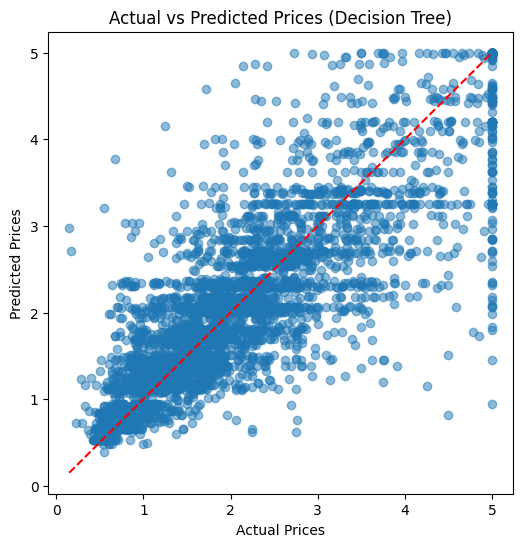

In [8]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, dt_predictions, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices (Decision Tree)")

plt.show()

In [9]:
print("\n========== FINAL CONCLUSION ==========")

if dt_r2 > lr_r2:
    print("The tuned Decision Tree model performed better than Linear Regression.")
else:
    print("Linear Regression performed better than the tuned Decision Tree.")

print("\nTask 3 Completed Successfully!")
print("✓ Train-Test Split")
print("✓ Cross Validation")
print("✓ Hyperparameter Tuning using GridSearchCV")
print("✓ Overfitting Control")
print("✓ RMSE Evaluation")
print("✓ R² Score Evaluation")
print("✓ Model Comparison")
print("✓ Visualization")


========== FINAL CONCLUSION ==========
The tuned Decision Tree model performed better than Linear Regression.

Task 3 Completed Successfully!
✓ Train-Test Split
✓ Cross Validation
✓ Hyperparameter Tuning using GridSearchCV
✓ Overfitting Control
✓ RMSE Evaluation
✓ R² Score Evaluation
✓ Model Comparison
✓ Visualization
